# Function Generation

Let $z \sim \mathcal{N}(0, \mathbb{I})$ a standard normal vector.

Construct a MLP s.t.
$$ f = MLP(z); \lVert \nabla f \rVert _2^2 \leq 1 $$

## Imports and Constants

In [1]:
import torch
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import pytorch_lightning as pl

from src.losses.losses import DirichletLoss
from src.models.generator import Generator
from torch.utils.data import DataLoader, TensorDataset

signal_length = 1000

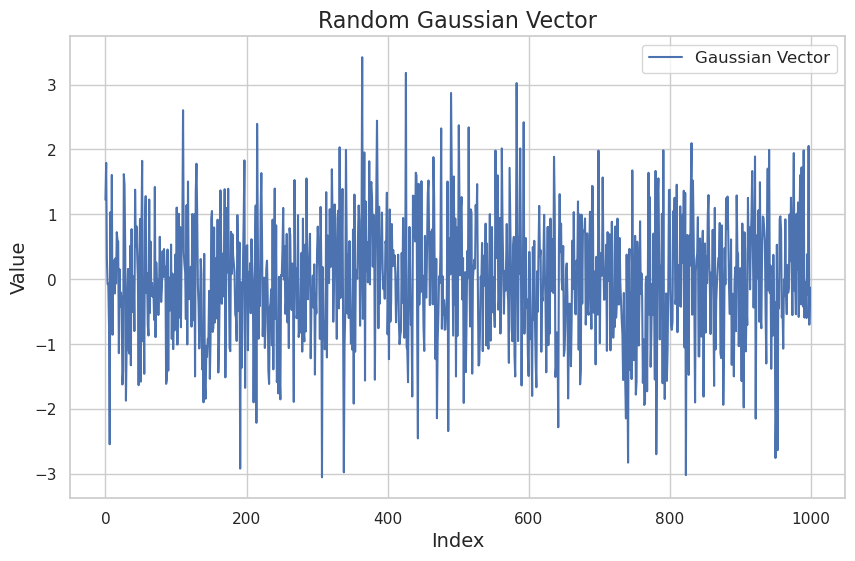

In [8]:
# Sample a random Gaussian vector of size 100
gaussian_vector = np.random.normal(loc=0.0, scale=1, size=signal_length)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=gaussian_vector, label="Gaussian Vector", color='b')
plt.title("Random Gaussian Vector", fontsize=16)
plt.xlabel("Index", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


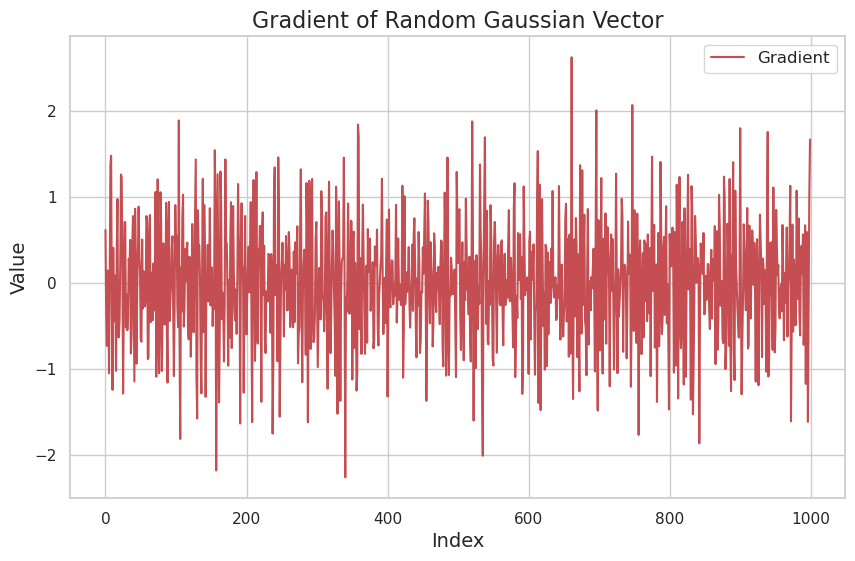

In [3]:
gradient = np.gradient(gaussian_vector)

plt.figure(figsize=(10, 6))
sns.lineplot(data=gradient, label="Gradient", color='r')
plt.title("Gradient of Random Gaussian Vector", fontsize=16)
plt.xlabel("Index", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [4]:
dirichlet_energy = np.sum(np.square(gradient))

## Test models

<class 'torch.Tensor'>


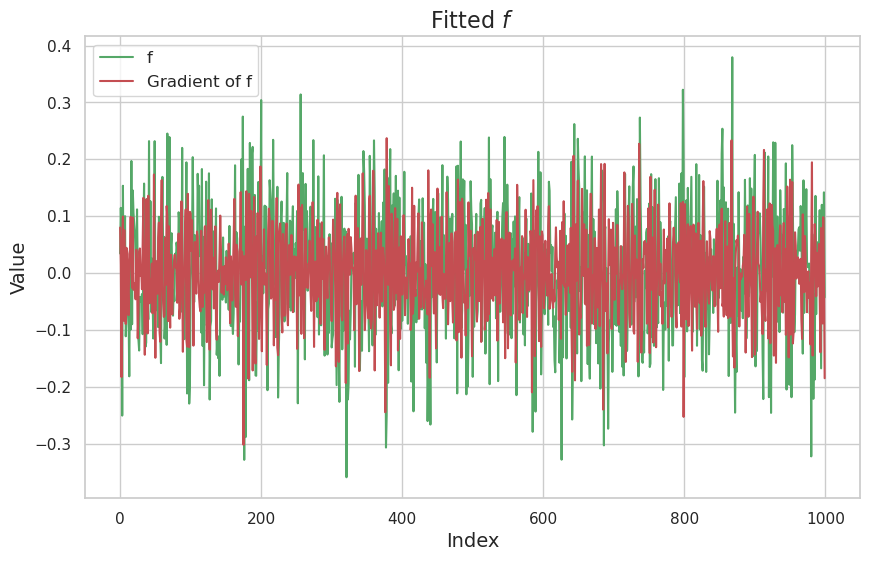

Dirichlet Energy of the fitted signal: 28.452417373657227, Original Dirichlet Energy: 6.334080696105957


In [5]:
criterion = DirichletLoss()
generator = Generator(signal_length, 256, signal_length)

f = generator(torch.from_numpy(gaussian_vector).float())
print(type(f))
loss = criterion(f.reshape(1, -1))
f = np.array(f.detach())
f_gradient = np.gradient(f)

dirichlet_energy = np.sum(np.square(f_gradient))


plt.figure(figsize=(10, 6))
sns.lineplot(data=f, label="f", color='g')
sns.lineplot(data=f_gradient, label="Gradient of f", color='r')
plt.title("Fitted $f$", fontsize=16)
plt.xlabel("Index", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print(f"Dirichlet Energy of the fitted signal: {loss.item()}, Original Dirichlet Energy: {dirichlet_energy}")

In [6]:
# Generate synthetic data for demonstration
hidden_dim = 256
batch_size = 1024
num_samples = 100_000

# Random synthetic dataset
x_data = torch.rand((num_samples, signal_length))

# DataLoader
dataset = TensorDataset(x_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model initialization
model = Generator(input_dim=signal_length, hidden_dim=hidden_dim, output_dim=signal_length, lr=1e-3)

# Trainer
trainer = pl.Trainer(max_epochs=100, log_every_n_steps=10)

# Train the model
trainer.fit(model, dataloader)

/home/arkadi.piven/miniconda3/envs/geometry/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/arkadi.piven/miniconda3/envs/geometry/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/arkadi.piven/miniconda3/envs/geometry/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/arkadi.piven/miniconda3/envs/geometry/lib/pyth ...
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_fl

Training: |          | 0/? [00:00<?, ?it/s]

torch.Size([1024, 1000])
tensor(1.4394, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.1443, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0066, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.1917, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0296, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0238, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0884, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0067, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0422, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0245, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0073, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024, 1000])
tensor(0.0411, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([1024

`Trainer.fit` stopped: `max_epochs=1` reached.


torch.Size([640, 1000])
tensor(5.3976e-08, device='cuda:0', grad_fn=<MeanBackward0>)


<class 'torch.Tensor'>


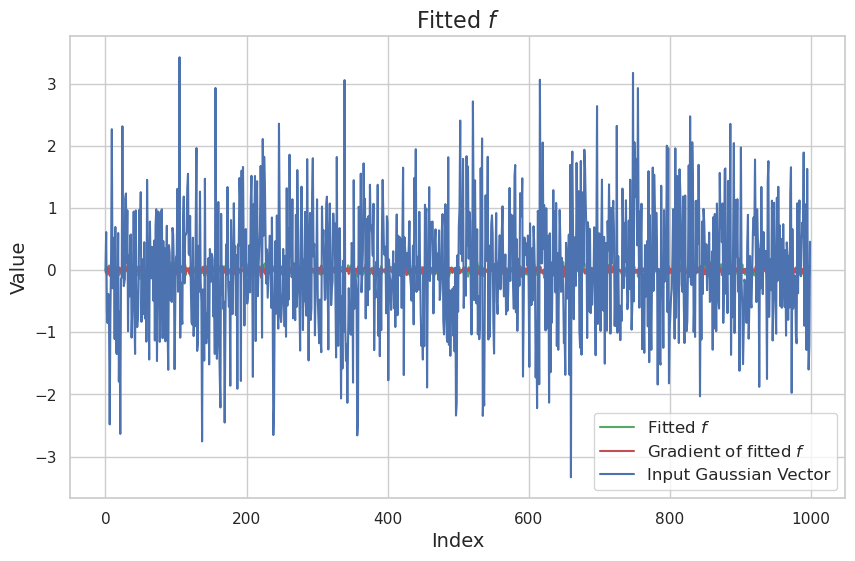

Dirichlet Energy of the fitted signal: 0.06929171085357666, Original Dirichlet Energy: 1.2632330656051636


In [7]:
f = model(torch.from_numpy(gaussian_vector).float())
print(type(f))
loss = criterion(f.reshape(1, -1))
f = np.array(f.detach())
f_gradient = np.gradient(f)

dirichlet_energy = np.sum(np.square(f_gradient))


plt.figure(figsize=(10, 6))
sns.lineplot(data=f, label="Fitted $f$", color='g')
sns.lineplot(data=f_gradient, label="Gradient of fitted $f$", color='r')
sns.lineplot(data=gaussian_vector, label="Input Gaussian Vector", color='b')
plt.title("Fitted $f$", fontsize=16)
plt.xlabel("Index", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print(f"Dirichlet Energy of the fitted signal: {loss.item()}, Original Dirichlet Energy: {dirichlet_energy}")